In [1]:
import os
import pandas as pd

ROUTES = [
    ("ParisMontparnasse_Bordeaux", "stop_area:SNCF:87391003", "stop_area:SNCF:87581009"),
    ("ParisMontparnasse_Rennes", "stop_area:SNCF:87391003", "stop_area:SNCF:87471003"),
    ("ParisMontparnasse_Nantes", "stop_area:SNCF:87391003", "stop_area:SNCF:87481002"),
    ("ParisMontparnasse_Toulouse", "stop_area:SNCF:87391003", "stop_area:SNCF:87611004"),
    ("ParisGareDuNord_Lille", "stop_area:SNCF:87271007", "stop_area:SNCF:87286005"),
    ("ParisEst_Strasbourg", "stop_area:SNCF:87113001", "stop_area:SNCF:87212027"),
    ("ParisGareDeLyon_LyonPartDieu","stop_area:SNCF:87686006", "stop_area:SNCF:87723197"),
    ("ParisGareDeLyon_Marseille", "stop_area:SNCF:87686006", "stop_area:SNCF:87751008"),
    ("ParisGareDeLyon_Montpellier_centre", "stop_area:SNCF:87686006", "stop_area:SNCF:87773002"),
    ("ParisGareDeLyon_Montpellier_sud", "stop_area:SNCF:87686006", "stop_area:SNCF:87688887"),
    ("ParisGareDeLyon_Grenoble", "stop_area:SNCF:87686006", "stop_area:SNCF:87747006"),
    ("ParisGareDeLyon_Belfort", "stop_area:SNCF:87686006", "stop_area:SNCF:87300822"),
]


def compute_retards(df_prevu, df_reel, date_str):
    df_prev = df_prevu.rename(columns={
        "Depart": "Depart_prevu",
        "Arrivee": "Arrivee_prevu",
        "Duree(min)": "Duree_prev"
    })

    df_rel = df_reel.rename(columns={
        "Depart": "Depart_reel",
        "Arrivee": "Arrivee_reel",
        "Duree(min)": "Duree_reel"
    })

    df_prev = df_prev.drop(columns=["Modes", "Statut"], errors="ignore")

    df = df_rel.merge(df_prev, on="Train", how="left")

    def to_dt(series):
        return pd.to_datetime(
            date_str + " " + series.astype(str),
            format="%Y-%m-%d %H:%M",
            errors="coerce"
        )

    df["Depart_prevu_dt"]  = to_dt(df["Depart_prevu"])
    df["Depart_reel_dt"]   = to_dt(df["Depart_reel"])
    df["Arrivee_prevu_dt"] = to_dt(df["Arrivee_prevu"])
    df["Arrivee_reel_dt"]  = to_dt(df["Arrivee_reel"])
    # Correction arrivée après minuit ou avance
    mask = df["Arrivee_reel_dt"] < df["Arrivee_prevu_dt"]

    # Différence (prévu - réel)
    diff = df["Arrivee_prevu_dt"] - df["Arrivee_reel_dt"]

    # Cas "arrivée après minuit" si avance apparente > 3h
    after_midnight = mask & (diff > pd.Timedelta(hours=3))

    # Cas "arrivée en avance normale" si avance apparente < 3h
    early_arrival = mask & (diff <= pd.Timedelta(hours=3))

    # Appliquer les corrections
    df.loc[after_midnight, "Arrivee_reel_dt"] += pd.Timedelta(days=1)

    # Pour les arrivées en avance : retard = 0
    df.loc[early_arrival, "Retard_arrivee(min)"] = 0
    
    df["Retard_arrivee(min)"] = (df["Arrivee_reel_dt"] - df["Arrivee_prevu_dt"]).dt.total_seconds() / 60

    df["Retard_depart(min)"]  = (df["Depart_reel_dt"]  - df["Depart_prevu_dt"]).dt.total_seconds() / 60
    
    df["Retard_duree(min)"]   = df["Duree_reel"] - df["Duree_prev"]

    return df[[
        "Train",
        "Depart_prevu", "Depart_reel", "Retard_depart(min)",
        "Arrivee_prevu", "Arrivee_reel", "Retard_arrivee(min)",
        "Duree_prev", "Duree_reel", "Retard_duree(min)",
        "Modes", "Statut"
    ]]


def process_all_routes(base_folder, date_str):
    

    for route_name, _, _ in ROUTES:
        file_prev = os.path.join(base_folder, f"{route_name}_prevu_{date_str}.csv")
        file_reel = os.path.join(base_folder, f"{route_name}_reel_{date_str}.csv")

        if not (os.path.exists(file_prev) and os.path.exists(file_reel)):
            print(f"Fichiers manquants pour {route_name}, ignoré.")
            continue

        print(f"Traitement de {route_name}...")

        df_prevu = pd.read_csv(file_prev)
        df_reel = pd.read_csv(file_reel)

        df_retards = compute_retards(df_prevu, df_reel, date_str)

        out_file = os.path.join(base_folder, f"{route_name}_retards_{date_str}.csv")
        df_retards.to_csv(out_file, index=False)

        print(f"Retards sauvegardés dans : {out_file}")


In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# --------------------------------------------------
# PARAMÈTRES GÉNÉRAUX
# --------------------------------------------------
root_folder = r"C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data"

start_date = datetime(2025, 11, 28)
end_date   = datetime(2026, 1, 19)

# Fusion Montpellier centre / sud
rename_map = {
    "ParisMontparnasse_Bordeaux": "Bordeaux",
    "ParisMontparnasse_Rennes": "Rennes",
    "ParisMontparnasse_Nantes": "Nantes",
    "ParisMontparnasse_Toulouse": "Toulouse",
    "ParisGareDuNord_Lille": "Lille",
    "ParisEst_Strasbourg": "Strasbourg",
    "ParisGareDeLyon_LyonPartDieu": "Lyon",
    "ParisGareDeLyon_Marseille": "Marseille",
    "ParisGareDeLyon_Grenoble": "Grenoble",
    "ParisGareDeLyon_Belfort": "Belfort",
    "ParisGareDeLyon_Montpellier_centre": "Montpellier",
    "ParisGareDeLyon_Montpellier_sud": "Montpellier",
}

# 1) LANCER process_all_routes POUR CHAQUE JOUR

current_date = start_date

while current_date <= end_date:
    date_str = current_date.strftime("%Y-%m-%d")
    day_folder = os.path.join(root_folder, date_str)

    if os.path.exists(day_folder):
        print(f"▶ Calcul des retards pour {date_str}")
        process_all_routes(day_folder, date_str)
    else:
        print(f"Dossier manquant : {day_folder}")

    current_date += timedelta(days=1)


# 2) CHARGER TOUS LES FICHIERS RETARDS 
all_dfs = []
current_date = start_date

while current_date <= end_date:
    date_str = current_date.strftime("%Y-%m-%d")
    day_folder = os.path.join(root_folder, date_str)

    if os.path.exists(day_folder):
        for filename in os.listdir(day_folder):
            if filename.endswith(f"retards_{date_str}.csv"):
                route_name = filename.replace(f"_retards_{date_str}.csv", "")

                if route_name in rename_map:
                    df = pd.read_csv(os.path.join(day_folder, filename))
                    df["Destination"] = rename_map[route_name]
                    df["Date"] = date_str
                    all_dfs.append(df)

    current_date += timedelta(days=1)

# Fusion globale multi-jours
df_global = pd.concat(all_dfs, ignore_index=True)



▶ Calcul des retards pour 2025-11-28
Traitement de ParisMontparnasse_Bordeaux...
Retards sauvegardés dans : C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-11-28\ParisMontparnasse_Bordeaux_retards_2025-11-28.csv
Traitement de ParisMontparnasse_Rennes...
Retards sauvegardés dans : C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-11-28\ParisMontparnasse_Rennes_retards_2025-11-28.csv
Traitement de ParisMontparnasse_Nantes...
Retards sauvegardés dans : C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-11-28\ParisMontparnasse_Nantes_retards_2025-11-28.csv
Traitement de ParisMontparnasse_Toulouse...
Retards sauvegardés dans : C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-11-28\ParisMontparnasse_Toulouse_retards_2025-11-28.csv
Traitement de ParisGareDuNord_Lille...
Retards sauvegardés dans : C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-11-28\ParisGareDuNord_Lille

In [20]:
df_global

,Train,Depart_prevu,Depart_reel,Retard_depart(min),Arrivee_prevu,Arrivee_reel,Retard_arrivee(min),Duree_prev,Duree_reel,Retard_duree(min),Modes,Statut,Destination,Date
0,9571,06:54,06:54,0.0,08:39,08:49,10.0,105.0,115,10.0,DB SNCF,SIGNIFICANT_DELAYS,Strasbourg,2025-11-28
1,9561,07:18,07:18,0.0,09:02,09:12,10.0,104.0,114,10.0,DB SNCF,SIGNIFICANT_DELAYS,Strasbourg,2025-11-28
2,2057,07:58,07:58,0.0,09:59,09:59,0.0,121.0,121,0.0,TGV INOUI,NaN,Strasbourg,2025-11-28
3,2429,09:25,09:25,0.0,11:11,11:11,0.0,106.0,106,0.0,TGV INOUI,NaN,Strasbourg,2025-11-28
4,9591,09:55,09:55,0.0,11:40,11:40,0.0,105.0,105,0.0,DB SNCF,NaN,Strasbourg,2025-11-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7563,8651,19:57,19:57,0.0,21:25,21:25,0.0,88.0,88,0.0,TGV INOUI,NaN,Rennes,2026-01-19
7564,8063,21:15,21:15,0.0,23:09,23:09,0.0,114.0,114,0.0,TGV INOUI,NaN,Rennes,2026-01-19
7565,8501,06:08,06:08,0.0,10:44,10:44,0.0,276.0,276,0.0,TGV INOUI,NaN,Toulouse,2026-01-19
7566,7671,08:26,08:26,0.0,13:17,13:17,0.0,290.0,290,0.0,OUIGO,NaN,Toulouse,2026-01-19


In [37]:
indicateur = (
    df_global
    .groupby(['Destination'])
    .agg(
        retard_total=('Retard_arrivee(min)', 'sum'),
        duree_totale=('Duree_prev', 'sum')
    )
    .assign(indicateur_retard=lambda x: x.retard_total / x.duree_totale)
    .reset_index()
)

In [38]:
indicateur

,Destination,retard_total,duree_totale,indicateur_retard
0,Belfort,2735.0,52022.0,0.052574
1,Bordeaux,4200.0,118087.0,0.035567
2,Grenoble,3865.0,64493.0,0.059929
3,Lille,2545.0,42210.0,0.060294
4,Lyon,6220.0,112987.0,0.055051
5,Marseille,7580.0,166423.0,0.045547
6,Montpellier,5955.0,109865.0,0.054203
7,Nantes,3115.0,89828.0,0.034677
8,Rennes,3595.0,86715.0,0.041458
9,Strasbourg,6040.0,89903.0,0.067184


In [ ]:
indicateur = (
    df_global
    .groupby(['Date', 'Destination'])
    .agg(
        retard_total=('Retard_arrivee(min)', 'sum'),
        duree_totale=('Duree_prev', 'sum')
    )
    .assign(indicateur_retard=lambda x: x.retard_total / x.duree_totale)
    .reset_index()
)

In [24]:
pivot_heatmap = indicateur.pivot(
    index='Date',
    columns='Destination',
    values='indicateur_retard'
)

In [35]:
ordre_lignes = [
    'Belfort',
    'Grenoble',
    'Lyon',
    'Montpellier',
    'Marseille',
    'Rennes',
    'Nantes',
    'Bordeaux',
    'Toulouse',
    'Lille',
    'Strasbourg'
]
# ordre_lignes = [
    
#     'Marseille',
#     'Rennes',
#     'Bordeaux',
#     'Lille',
#     'Strasbourg'
# ]

pivot_ordre = pivot_heatmap.reindex(columns=ordre_lignes)

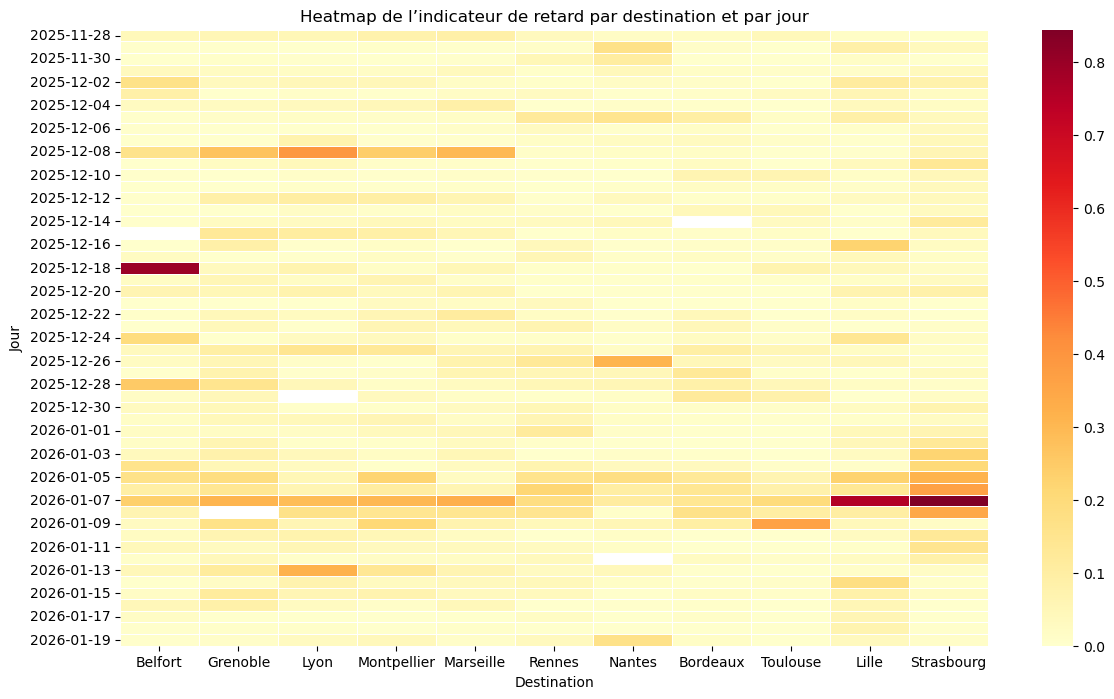

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_ordre,
    cmap='YlOrRd',
    linewidths=0.5
)



plt.title("Heatmap de l’indicateur de retard par destination et par jour")
plt.xlabel("Destination")
plt.ylabel("Jour")
plt.show()

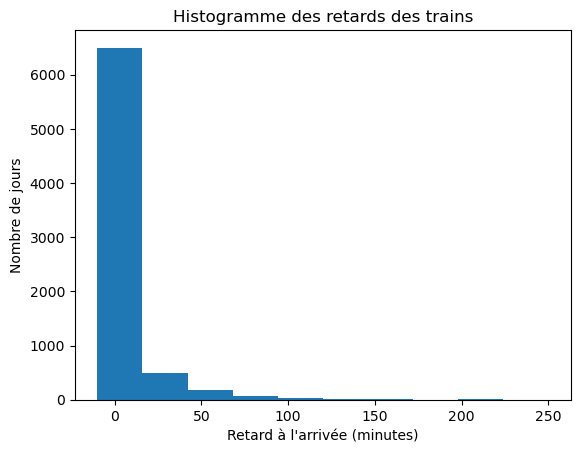

In [3]:
import matplotlib.pyplot as plt

plt.hist(df_global['Retard_arrivee(min)'], bins=10)
plt.xlabel("Retard à l'arrivée (minutes)")
plt.ylabel("Nombre de jours")
plt.title("Histogramme des retards des trains")
plt.show()

In [4]:
import pandas as pd

bins = [0, 5, 30, 120, 180, float('inf')]
labels = [
    'Pas de retard',
    'Entre 5 et 30 minutes',
    'Entre 30 min et 2h',
    'Entre 2 et 3h',
    'Plus de 3h'
]

df_global['categorie_retard'] = pd.cut(
    df_global['Retard_arrivee(min)'],
    bins=bins,
    labels=labels,
    right=False
)

In [5]:
nombre = df_global['categorie_retard'].value_counts().sort_index()


In [6]:
proportion = df_global['categorie_retard'].value_counts(normalize=True).sort_index() * 100
resultat = pd.DataFrame({
    'Nombre': nombre,
    'Proportion (%)': proportion.round(2)
})

print(resultat)

                       Nombre  Proportion (%)
Pas de retard            5181           71.05
Entre 5 et 30 minutes    1569           21.52
Entre 30 min et 2h        500            6.86
Entre 2 et 3h              32            0.44
Plus de 3h                 10            0.14


In [12]:
start_date = datetime(2025, 11, 28)
end_date   = datetime(2026, 1, 19)

# Dossier racine
base_path = r"C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data"

# Liste des DataFrames
dfs = []

current_date = start_date
while current_date <= end_date:
    date_str = current_date.strftime("%Y-%m-%d")

    file_path = os.path.join(
        base_path,
        date_str,
        f"ParisMontparnasse_Bordeaux_retards_{date_str}.csv"
    )

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['date'] = date_str  
        dfs.append(df)
   
        

    current_date += timedelta(days=1)

# Agrégation finale
df_global= pd.concat(dfs, ignore_index=True)


In [17]:
df_global

,Train,Depart_prevu,Depart_reel,Retard_depart(min),Arrivee_prevu,Arrivee_reel,Retard_arrivee(min),Duree_prev,Duree_reel,Retard_duree(min),Modes,Statut,date,categorie_retard
0,8501,06:11,06:11,0.0,08:14,08:34,20.0,123.0,143,20.0,TGV INOUI,SIGNIFICANT_DELAYS,2025-11-28,Entre 5 et 30 minutes
1,8571,06:38,06:38,0.0,08:48,08:48,0.0,130.0,130,0.0,TGV INOUI,NaN,2025-11-28,Pas de retard
2,12251,07:11,07:11,0.0,09:14,09:14,0.0,123.0,123,0.0,TGV INOUI,NaN,2025-11-28,Pas de retard
3,8423,08:01,08:01,0.0,10:18,10:18,0.0,137.0,137,0.0,TGV INOUI,NaN,2025-11-28,Pas de retard
4,7671,08:29,08:34,5.0,10:34,10:39,5.0,124.0,124,0.0,OUIGO,SIGNIFICANT_DELAYS,2025-11-28,Entre 5 et 30 minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,8593,18:08,18:08,0.0,20:17,20:17,0.0,129.0,129,0.0,TGV INOUI,NaN,2026-01-19,Pas de retard
978,8551,NaN,18:41,NaN,NaN,20:49,NaN,NaN,128,NaN,TGV INOUI,NaN,2026-01-19,NaN
979,8419,19:11,19:26,15.0,21:17,21:27,10.0,126.0,121,-5.0,TGV INOUI,SIGNIFICANT_DELAYS,2026-01-19,Entre 5 et 30 minutes
980,7659,19:50,19:50,0.0,22:57,22:57,0.0,186.0,186,0.0,OUIGO,NaN,2026-01-19,Pas de retard


In [16]:
indicateur = (
    df_global
    .groupby(['date', 'ligne'])
    .agg(
        retard_total=('Retard_arrivee(min)', 'sum'),
        duree_totale=('Duree_trajet(min)', 'sum')
    )
    .assign(indicateur_retard=lambda x: x.retard_total / x.duree_totale)
    .reset_index()
)

KeyError: 'ligne'

In [13]:

# Définition des catégories
bins = [0, 5, 30, 120, 180, float('inf')]
labels = [
    'Pas de retard',
    'Entre 5 et 30 minutes',
    'Entre 30 min et 2h',
    'Entre 2 et 3h',
    'Plus de 3h'
]

df_global['categorie_retard'] = pd.cut(
    df_global['Retard_arrivee(min)'],
    bins=bins,
    labels=labels,
    right=False
)

In [14]:
# S'assurer que la date est bien au format date
df_global['date'] = pd.to_datetime(df_global['date'])

# Tableau croisé : lignes = jours, colonnes = catégories
table = pd.crosstab(
    df_global['date'],
    df_global['categorie_retard']
).sort_index()
colors = [
    '#2ecc71',  # vert
    '#a3e635',  # vert-jaune
    '#facc15',  # jaune
    '#fb923c',  # orange
    '#ef4444'   # rouge
]

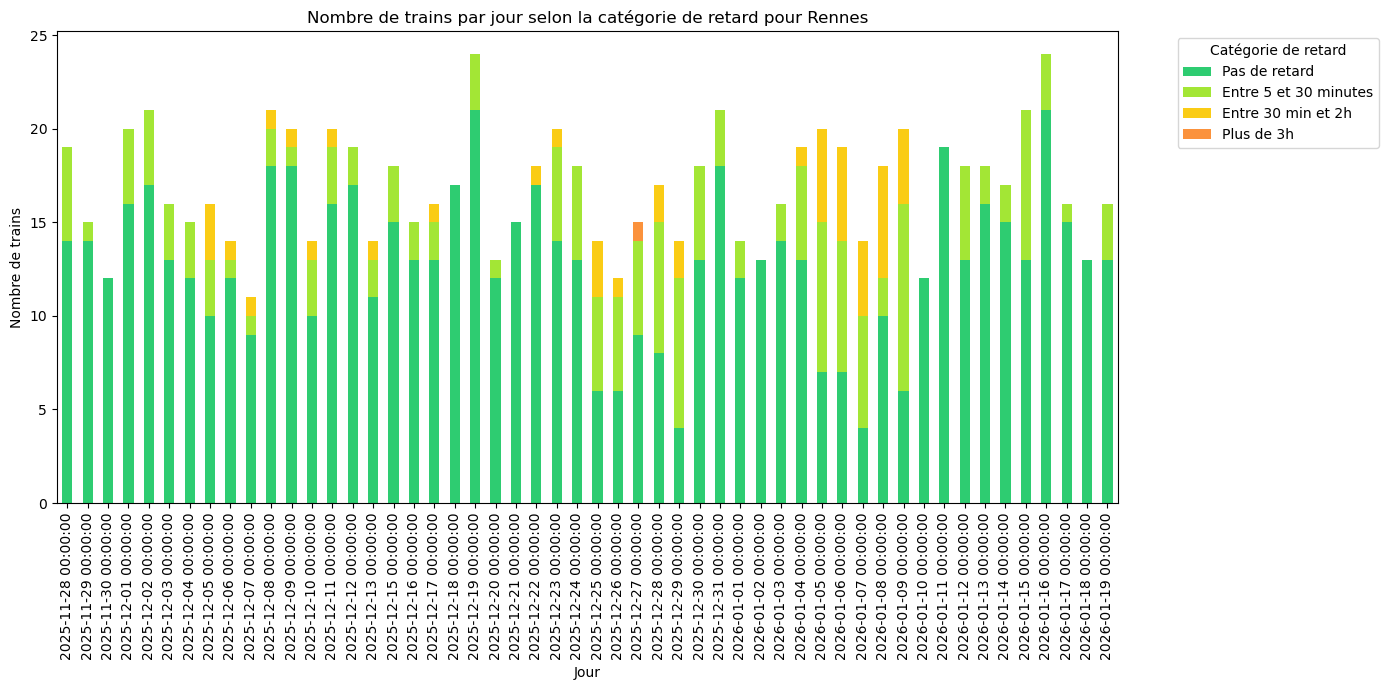

In [15]:
table.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    color=colors

)

plt.xlabel("Jour")
plt.ylabel("Nombre de trains")
plt.title("Nombre de trains par jour selon la catégorie de retard pour Rennes")
plt.legend(title="Catégorie de retard", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
df_global_1 

,Train,Depart_prevu,Depart_reel,Retard_depart(min),Arrivee_prevu,Arrivee_reel,Retard_arrivee(min),Duree_prev,Duree_reel,Retard_duree(min),Modes,Statut,date
0,9713,07:41,07:41,0.0,10:59,11:04,5.0,198.0,203,5.0,TGV INOUI,SIGNIFICANT_DELAYS,2025-11-28
1,6275,10:55,10:55,0.0,14:08,14:08,0.0,193.0,193,0.0,TGV INOUI,NaN,2025-11-28
2,7875,11:45,11:45,0.0,15:04,15:04,0.0,198.0,198,0.0,OUIGO,NaN,2025-11-28
3,6277,16:55,17:40,45.0,20:11,20:56,45.0,196.0,196,0.0,TGV INOUI,SIGNIFICANT_DELAYS,2025-11-28
4,6279,18:55,19:10,15.0,22:08,22:48,40.0,193.0,218,25.0,TGV INOUI,SIGNIFICANT_DELAYS,2025-11-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,9713,07:42,07:42,0.0,10:57,11:02,5.0,195.0,200,5.0,TGV INOUI,SIGNIFICANT_DELAYS,2026-01-06
195,6275,10:56,10:56,0.0,14:10,14:20,10.0,194.0,204,10.0,TGV INOUI,SIGNIFICANT_DELAYS,2026-01-06
196,7875,11:45,11:45,0.0,15:00,15:00,0.0,194.0,194,0.0,OUIGO,NaN,2026-01-06
197,6277,16:56,17:31,35.0,20:11,21:11,60.0,195.0,220,25.0,TGV INOUI,SIGNIFICANT_DELAYS,2026-01-06


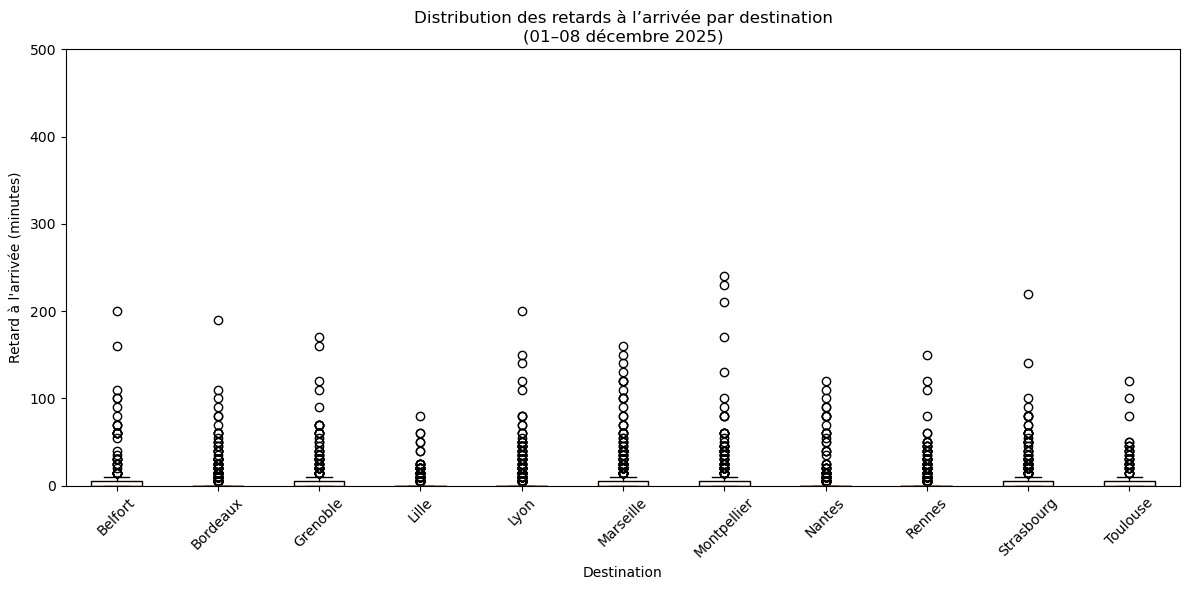

In [ ]:
import matplotlib.pyplot as plt

# Nettoyage : garder seulement les retards valides
df_box = df_global[
    df_global["Retard_arrivee(min)"].notna()
]

# Ordonner les destinations (optionnel mais plus lisible)
order = sorted(df_box["Destination"].unique())

# Préparer les données pour matplotlib
data = [
    df_box[df_box["Destination"] == dest]["Retard_arrivee(min)"]
    for dest in order
]

# Création du boxplot
plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=order, showfliers=True)

plt.ylim(0, 500)

plt.title("Distribution des retards à l’arrivée par destination\n(duree)")
plt.xlabel("Destination")
plt.ylabel("Retard à l'arrivée (minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

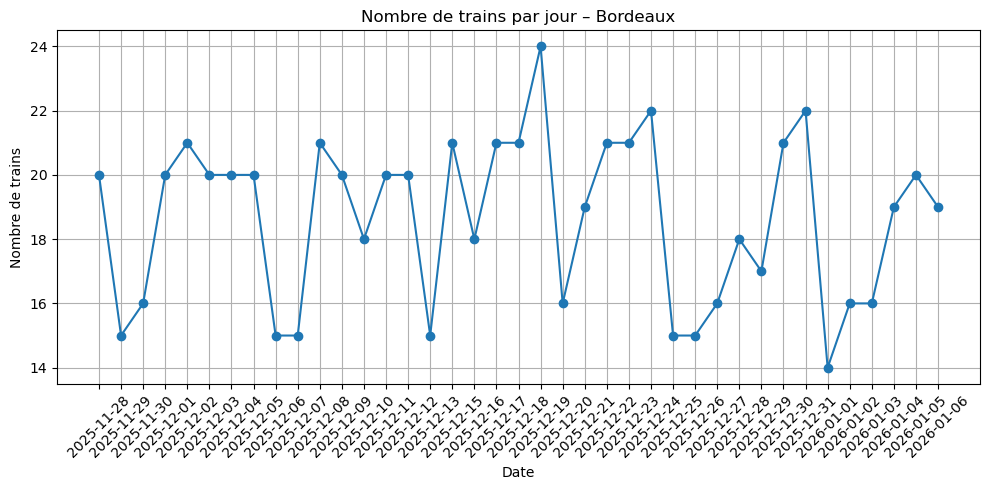

In [12]:
destination = "Bordeaux"   


# FILTRAGE

df_dest = df_global[
    df_global["Destination"] == destination
]


trains_per_day = (
    df_dest
    .groupby("Date")["Arrivee_reel"]
    .count()
    .reset_index(name="Nb_trains")
)


trains_per_day = trains_per_day.sort_values("Date")

plt.figure(figsize=(10, 5))
plt.plot(trains_per_day["Date"], trains_per_day["Nb_trains"], marker="o")

plt.title(f"Nombre de trains par jour – {destination}")
plt.xlabel("Date")
plt.ylabel("Nombre de trains")
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# RAPPORT GLOBAL MULTI-JOURS
summary = df_global.groupby("Destination").agg(
    Duree_reel_moyenne=("Duree_reel", "mean"),
    Retard_arrivee_moyen=("Retard_arrivee(min)", "mean"),
    Nb_trains=("Arrivee_reel", "count"),
).reset_index()

# Sauvegarde CSV global
report_path = os.path.join(
    root_folder,
    "rapport_global_retards_2025-12-01_au_2025-12-08.csv"
)
summary.to_csv(report_path, index=False)

print("\nRapport global créé :")
print(report_path)
print(summary)


Rapport global créé :
C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\rapport_global_retards_2025-12-01_au_2025-12-08.csv
    Destination  Duree_reel_moyenne  Retard_arrivee_moyen  Nb_trains
0       Belfort          150.146718              8.249027        259
1      Bordeaux          134.924451              4.686544        728
2      Grenoble          183.747212              9.516729        269
3         Lille           68.249476              3.008386        477
4          Lyon          121.935028              5.177557        708
5     Marseille          200.312210              7.763780        647
6   Montpellier          207.189573              9.029126        422
7        Nantes          132.067708              4.271028        576
8        Rennes           98.812772              3.897397        689
9    Strasbourg          114.356269              6.307087        654
10     Toulouse          283.583333              5.646388        264


In [ ]:
import matplotlib.pyplot as plt

# -----------------------------------------
# PARAMÈTRES
# -----------------------------------------
process_all_routes(
    r"C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-12-01",
    "2025-12-01"
)

base_folder = r"C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-12-01"
date_str = "2025-12-01"

# Fusion Montpellier centre / sud
rename_map = {
    "ParisMontparnasse_Bordeaux": "Bordeaux",
    "ParisMontparnasse_Rennes": "Rennes",
    "ParisMontparnasse_Nantes": "Nantes",
    "ParisMontparnasse_Toulouse": "Toulouse",
    "ParisGareDuNord_Lille": "Lille",
    "ParisEst_Strasbourg": "Strasbourg",
    "ParisGareDeLyon_LyonPartDieu": "Lyon",
    "ParisGareDeLyon_Marseille": "Marseille",
    "ParisGareDeLyon_Grenoble": "Grenoble",
    "ParisGareDeLyon_Belfort": "Belfort",

    # fusion Montpellier centre + sud
    "ParisGareDeLyon_Montpellier_centre": "Montpellier",
    "ParisGareDeLyon_Montpellier_sud": "Montpellier",
}

# -----------------------------------------
# 1) CHARGER LES 12 FICHIERS DE RETARDS
# -----------------------------------------
all_dfs = []

for filename in os.listdir(base_folder):
    if filename.endswith(f"retards_{date_str}.csv"):
        route_name = filename.replace(f"_retards_{date_str}.csv", "")

        if route_name in rename_map:
            df = pd.read_csv(os.path.join(base_folder, filename))

            # Ajouter destination simplifiée
            df["Destination"] = rename_map[route_name]

            all_dfs.append(df)
        else:
            print(f"⚠️ Route inconnue ignorée : {route_name}")

# Fusion globale
df_global = pd.concat(all_dfs, ignore_index=True)

# -----------------------------------------
# 2) AGGRÉGATION AVEC "nombre de trains"
# -----------------------------------------
summary = df_global.groupby("Destination").agg({
    "Duree_reel": "mean",
    "Retard_arrivee(min)": "mean",
    "Arrivee_reel": "count",    # <= Ici : nombre de trains
}).reset_index()

# Renommer proprement la colonne
summary = summary.rename(columns={"Arrivee_reel": "Nb_trains"})

# Sauvegarde du rapport CSV
report_path = os.path.join(base_folder, f"rapport_global_retards_{date_str}.csv")
summary.to_csv(report_path, index=False)

print("Rapport global créé :")
print(report_path)
print(summary)

Rapport global créé :
C:\Users\nguye\OneDrive\Documents\Ponts\Mobilite connectee\sncf_data\2025-12-01\rapport_global_retards_2025-12-01.csv
    Destination  Duree_reel  Retard_arrivee(min)  Nb_trains
0       Belfort  154.166667             5.000000          6
1      Bordeaux  133.000000             1.750000         20
2      Grenoble  180.142857             4.285714          7
3         Lille   67.785714             0.714286         14
4          Lyon  121.190476             2.619048         21
5     Marseille  200.625000             7.666667         16
6   Montpellier  205.333333             3.750000         12
7        Nantes  130.333333             5.000000         18
8        Rennes   93.500000             0.625000         16
9    Strasbourg  115.529412             4.411765         17
10     Toulouse  282.285714             3.571429          7
